<a href="https://colab.research.google.com/github/tukamilano/Semi-Thue/blob/main/Levenshtein_%E5%AD%A6%E7%BF%92%E7%94%A8%E3%83%87%E3%83%BC%E3%82%BF%E3%81%AE%E5%8F%8E%E9%9B%86.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

search_modeはgbfs(模倣学習に用いるデータ)

In [ ]:
!pip -q install python-Levenshtein pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 38.6 MB/s eta 0:00:00


In [ ]:
import os, time, random, json, heapq
from typing import List, Tuple, Optional, Dict, Any
from Levenshtein import distance as levenshtein_distance

# =========================================
# Fixed config (rules are generated once and reused)
# =========================================
OUTPUT_DIR = "/content/bfs_experiments"
DATASET_PATH = os.path.join(OUTPUT_DIR, "dataset_gbfs_trajectories.jsonl")
RULES_PATH   = os.path.join(OUTPUT_DIR, "rules.json")

CONFIG_RULES = {"alphabet_num": 25, "rule_num": 500, "p": 0.20}
N_TRIALS = 100
THRESHOLD_EXPANSIONS = 100_000  # stop expanding once this many nodes are generated

os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================================
# Utilities: alphabet & rules
# =========================================
Alphabet = Tuple[str, ...]
Rule = Tuple[str, str]
TrajectoryStep = Dict[str, Any]  # {state, rule:[lhs,rhs], next_state}


def make_alphabet(alphabet_num: int) -> Alphabet:
    # Uppercase letters; if >26, continue with ASCII after 'Z'
    return tuple(chr(65 + (i % 26)) for i in range(alphabet_num))

def sample_geometric_len(p: float) -> int:
    # P(L = k) = (1-p)^k p, support k=0,1,2,...
    i = 0
    while True:
        if random.random() < p:
            return i
        i += 1


def generate_rules(alphabet: Alphabet, rule_num: int, p: float,
                   allow_epsilon_lhs: bool = True,
                   allow_epsilon_rhs: bool = True) -> List[Rule]:
    rules = set()
    while len(rules) < rule_num:
        i = sample_geometric_len(p)
        j = sample_geometric_len(p)
        if (not allow_epsilon_lhs and i == 0) or (not allow_epsilon_rhs and j == 0):
            continue
        before = ''.join(random.choices(alphabet, k=i))
        after  = ''.join(random.choices(alphabet, k=j))
        if before == after:
            continue
        rules.add((before, after))
    return list(rules)

# =========================================
# GBFS that returns the successful trajectory (or None)
# =========================================

def gbfs_trajectory(before: str, after: str, rules: List[Rule], *,
                    threshold: int = THRESHOLD_EXPANSIONS) -> Optional[List[TrajectoryStep]]:
    """
    Greedy Best-First Search guided by Levenshtein distance.
    Returns a list of steps [{state, rule:[lhs,rhs], next_state}, ...] if goal is reached,
    otherwise returns None. Stops when expanded nodes reach 'threshold'.
    """
    if before == after:
        return []  # empty trajectory

    # Min-heap by heuristic only.
    pq: List[Tuple[int, int, str]] = [(levenshtein_distance(before, after), 0, before)]

    visited = {before}
    # For path reconstruction: child -> (parent, rule)
    parent: Dict[str, Tuple[str, Rule]] = {}

    expanded = 0

    while pq:
        h, depth, current = heapq.heappop(pq)

        # Expand neighbors generated by applying each rule at all valid positions
        for lhs, rhs in rules:
            blen = len(lhs)
            if blen == 0:
                positions = range(len(current) + 1)
            else:
                if len(current) < blen:
                    continue
                positions = range(len(current) - blen + 1)

            for pos in positions:
                if current[pos:pos+blen] == lhs:
                    new_state = current[:pos] + rhs + current[pos+blen:]
                    if new_state in visited:
                        continue
                    visited.add(new_state)
                    parent[new_state] = (current, (lhs, rhs))
                    expanded += 1

                    if new_state == after:
                        # Reconstruct path (backwards) then turn into trajectory steps
                        path_nodes = [after]
                        while path_nodes[-1] != before:
                            prev, rule = parent[path_nodes[-1]]
                            path_nodes.append(prev)
                        path_nodes.reverse()
                        # Make steps
                        steps: List[TrajectoryStep] = []
                        for s, t in zip(path_nodes[:-1], path_nodes[1:]):
                            _, rule = parent[t]
                            steps.append({
                                "state": s,
                                "rule": [rule[0], rule[1]],
                                "next_state": t,
                            })
                        return steps

                    # Push into frontier with heuristic priority
                    heapq.heappush(pq, (levenshtein_distance(new_state, after), depth + 1, new_state))

                    if expanded >= threshold:
                        return None

    # Frontier exhausted without reaching goal
    return None

# =========================================
# Trial driver (no statistics, returns/writes raw trajectories)
# =========================================

def run_trials(n_trials: int = N_TRIALS,
               threshold: int = THRESHOLD_EXPANSIONS,
               rules_config: Dict[str, Any] = CONFIG_RULES,
               dataset_path: str = DATASET_PATH,
               rules_path: str = RULES_PATH,
               base_seed: Optional[int] = None) -> None:
    # Fix rules once
    if base_seed is None:
        base_seed = random.randrange(10**9)
    rng_rules = random.Random(base_seed)

    alphabet = make_alphabet(rules_config["alphabet_num"])
    # Generate rules with a separate RNG so trials are reproducible given base_seed
    random.setstate(rng_rules.getstate())
    rules = generate_rules(alphabet, rules_config["rule_num"], rules_config["p"],
                           allow_epsilon_lhs=True, allow_epsilon_rhs=True)

    # Save rules for reuse
    with open(rules_path, "w") as f:
        json.dump({"config": rules_config, "rules": rules, "base_seed": base_seed}, f, ensure_ascii=False)

    # Trials: for each, draw before/after via geometric length with the same p
    t0 = time.time()
    with open(dataset_path, "w") as out:
        for t in range(n_trials):
            seed_t = (base_seed + 2654435761 * (t + 1)) & 0x7fffffff
            random.seed(seed_t)

            i = sample_geometric_len(rules_config["p"])  # length of before
            j = sample_geometric_len(rules_config["p"])  # length of after
            before = ''.join(random.choices(alphabet, k=i))
            after  = ''.join(random.choices(alphabet, k=j))

            traj = gbfs_trajectory(before, after, rules, threshold=threshold)

            rec = {
                "trial": t,
                "seed": seed_t,
                "before": before,
                "after": after,
                "trajectory": traj,  # None if threshold/unreachable, else list of {state, rule, next_state}
            }
            out.write(json.dumps(rec, ensure_ascii=False) + "\n")

            if (t + 1) % 20 == 0 or (t + 1) == n_trials:
                elapsed = time.time() - t0
                print(f"[{t+1}/{n_trials}] elapsed={elapsed:.1f}s")


if __name__ == "__main__":
    run_trials()
    print("Saved:", DATASET_PATH)
    print("Rules:", RULES_PATH)



[20/100] elapsed=3.6s
[40/100] elapsed=7.0s
[60/100] elapsed=11.6s
[80/100] elapsed=14.9s
[100/100] elapsed=18.4s
Saved: /content/bfs_experiments/dataset_gbfs_trajectories.jsonl
Rules: /content/bfs_experiments/rules.json


Success rate: 54.00%


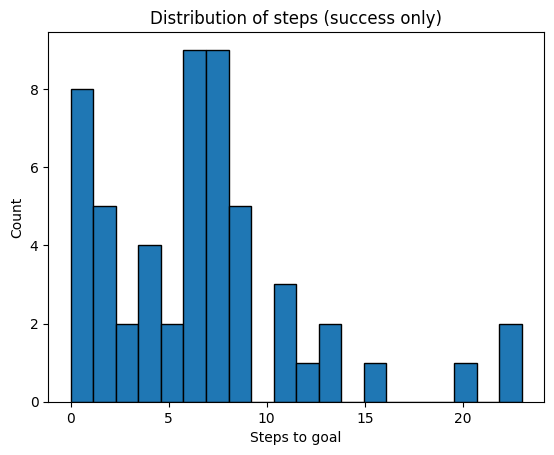

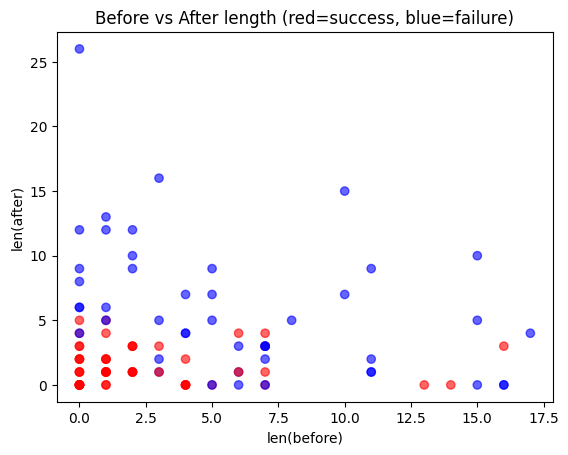

In [ ]:
import json
import matplotlib.pyplot as plt
import pandas as pd

# ===== データセット読み込み =====
DATASET_PATH = "/content/bfs_experiments/dataset_gbfs_trajectories.jsonl"

records = []
with open(DATASET_PATH, "r") as f:
    for line in f:
        rec = json.loads(line)
        records.append(rec)

df = pd.DataFrame(records)

# ===== 簡単な可視化例 =====
# 1. success / failure の割合
success_rate = df["trajectory"].notna().mean()
print(f"Success rate: {success_rate*100:.2f}%")

# 2. ステップ数（成功のみ）分布
steps = [len(traj) for traj in df["trajectory"] if traj is not None]

plt.figure()
plt.hist(steps, bins=20, edgecolor="k")
plt.xlabel("Steps to goal")
plt.ylabel("Count")
plt.title("Distribution of steps (success only)")
plt.show()

# 3. before/after の長さ分布
plt.figure()
plt.scatter(df["before"].str.len(), df["after"].str.len(),
            c=df["trajectory"].notna(), cmap="bwr", alpha=0.6)
plt.xlabel("len(before)")
plt.ylabel("len(after)")
plt.title("Before vs After length (red=success, blue=failure)")
plt.show()


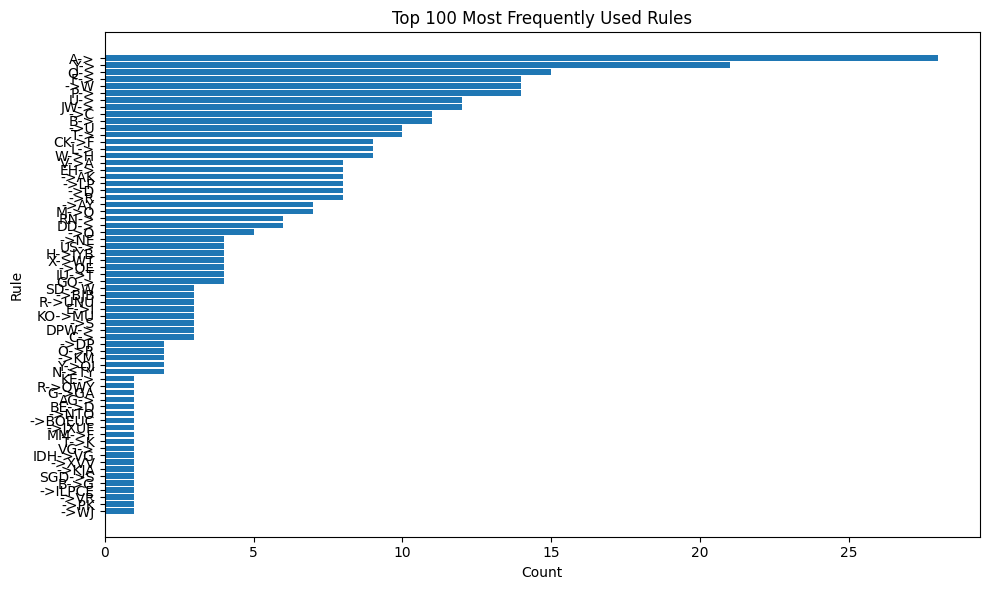

       rule  count
0       A->     28
1       Y->     21
2       Q->     15
3       F->     14
4       ->W     14
..      ...    ...
61     B->G      1
62  ->ILPCE      1
63     ->VR      1
64     ->PK      1
65     ->WJ      1

[66 rows x 2 columns]


In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# ===== データセット読み込み =====
DATASET_PATH = "/content/bfs_experiments/dataset_gbfs_trajectories.jsonl"

records = []
with open(DATASET_PATH, "r") as f:
    for line in f:
        records.append(json.loads(line))

# ===== ルール使用頻度集計 =====
rule_counter = Counter()
for rec in records:
    traj = rec.get("trajectory")
    if traj is None:
        continue
    for step in traj:
        lhs, rhs = step["rule"]
        rule_counter[(lhs, rhs)] += 1

# DataFrameに変換しソート
rule_df = pd.DataFrame(
    [ {"rule": f"{lhs}->{rhs}", "count": cnt} for (lhs, rhs), cnt in rule_counter.items() ]
)
rule_df = rule_df.sort_values("count", ascending=False).reset_index(drop=True)

# ===== 上位ルールの可視化 =====
TOP_K = 100  # 上位何個まで表示するか

plt.figure(figsize=(10,6))
plt.barh(rule_df["rule"].head(TOP_K)[::-1], rule_df["count"].head(TOP_K)[::-1])
plt.xlabel("Count")
plt.ylabel("Rule")
plt.title(f"Top {TOP_K} Most Frequently Used Rules")
plt.tight_layout()
plt.show()

# 表として確認
print(rule_df.head(100))
